# Build Image classifier using keras and tensarflow

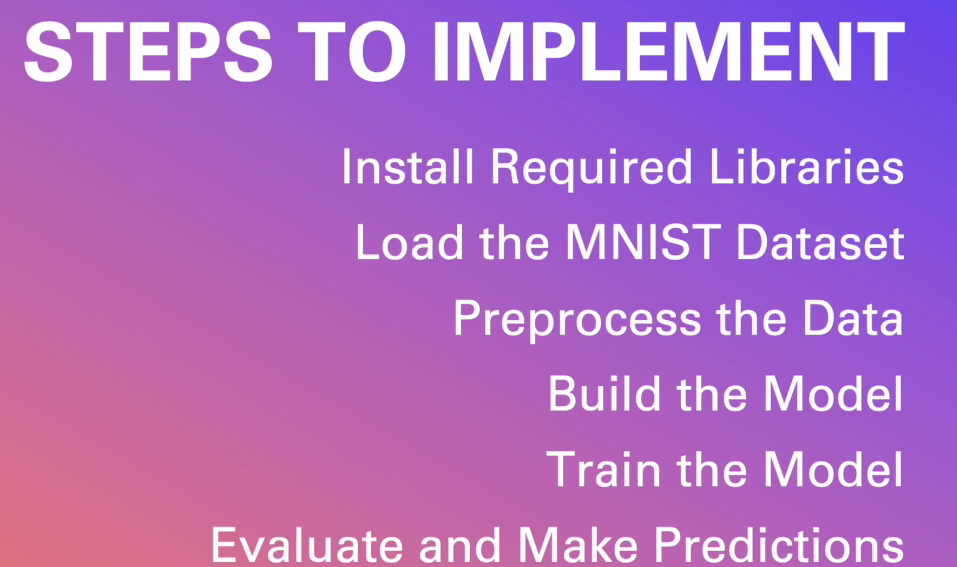

## Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

## Load the MNIST dataset

In [ ]:
(train_images, train_labels), (test_images, test_labels) = dataset.mnist.load_data()

## Preprocessing: Normalizing the pixel values to be between 0 and 1

In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

## Reshape the images to (28,28,1) as they are grayscale

In [ ]:
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

## convert the labels into one-hot encoded format

In [ ]:
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

## Build the CNN model

In [ ]:
model = models.Sequential()

## First convolutional layer

In [ ]:
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

## Second convolutional layer

In [ ]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

## Third convolutional layer

In [1]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))

NameError: name 'model' is not defined

## Flatten the 3D output to 1D and add a Dense Layer

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'relu'))

## Output layer with 10 neurons (for 10 digit classes)

In [ ]:
model.add(layers.Dense(10, activation='softmax'))

## Compile the model

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', matrics=['accuracy'])

## Train model 

In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))

## Evaluate the model on the test data

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

## Make predictions on test images

In [ ]:
predictions = model.predict(test_images)
print(f"Prediction for first test image: {np.argmax(predictions[0])}")

In [ ]:
plt.imshow(test_images[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predictions[0].argmax()}")
plt.show()